Import Libraries

In [7]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler

Load Dataset

In [8]:
# Load Dataset
df = pd.read_csv("marketing_campaign.csv", sep="\t")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


Dataset Overview

In [9]:
print("Dataset Shape :", df.shape)

print("\nColumns\n")
print(df.columns.tolist())

print("\nData Types\n")
print(df.dtypes)

Dataset Shape : (2240, 29)

Columns

['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']

Data Types

ID                       int64
Year_Birth               int64
Education                  str
Marital_Status             str
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer                str
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWe

Dataset Information

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

Missing Values & Duplicate Records

In [11]:
print("Missing Values")

print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

Missing Values
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Duplicate Rows : 0


Data Cleaning

In [12]:
# Remove duplicate records
df.drop_duplicates(inplace=True)

# Fill missing Income values with median
df["Income"] = df["Income"].fillna(df["Income"].median())

print("Dataset Shape :", df.shape)

df.head()

Dataset Shape : (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


Feature Engineering

In [13]:
# Current Year
current_year = 2026

# Customer Age
df["Age"] = current_year - df["Year_Birth"]

# Total Children
df["Children"] = df["Kidhome"] + df["Teenhome"]

# Total Spending

df["TotalSpending"] = (
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Children,TotalSpending
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,3,11,1,69,0,1617
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,3,11,0,72,2,27
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,3,11,0,61,0,776
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,3,11,0,42,1,53
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,3,11,0,45,1,422


Statistical Summary

In [14]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Children,TotalSpending
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52237.975446,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,57.194196,0.950446,605.798214
std,3246.662198,11.984069,25037.955891,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,11.984069,0.751803,602.249288
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,30.000000,0.000000,5.000000
25%,2828.250000,1959.000000,35538.750000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,49.000000,0.000000,68.750000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,56.000000,1.000000,396.000000
75%,8427.750000,1977.000000,68289.750000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,67.000000,1.000000,1045.500000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,133.000000,3.000000,2525.000000


Customer Spending Distribution

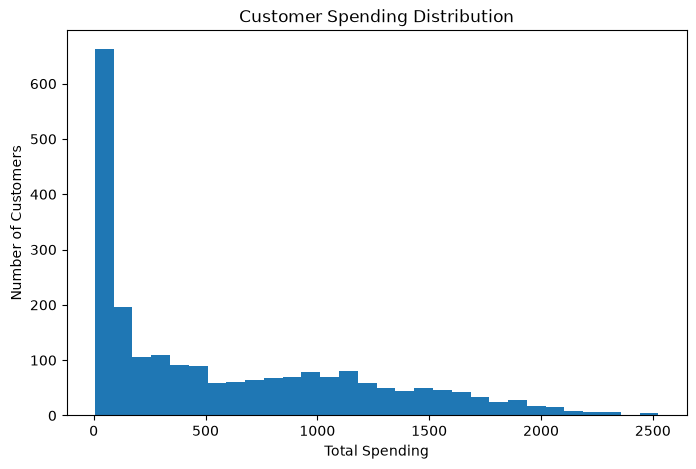

In [15]:
plt.figure(figsize=(8,5))

plt.hist(df["TotalSpending"], bins=30)

plt.title("Customer Spending Distribution")

plt.xlabel("Total Spending")

plt.ylabel("Number of Customers")

plt.show()

Correlation Heatmap

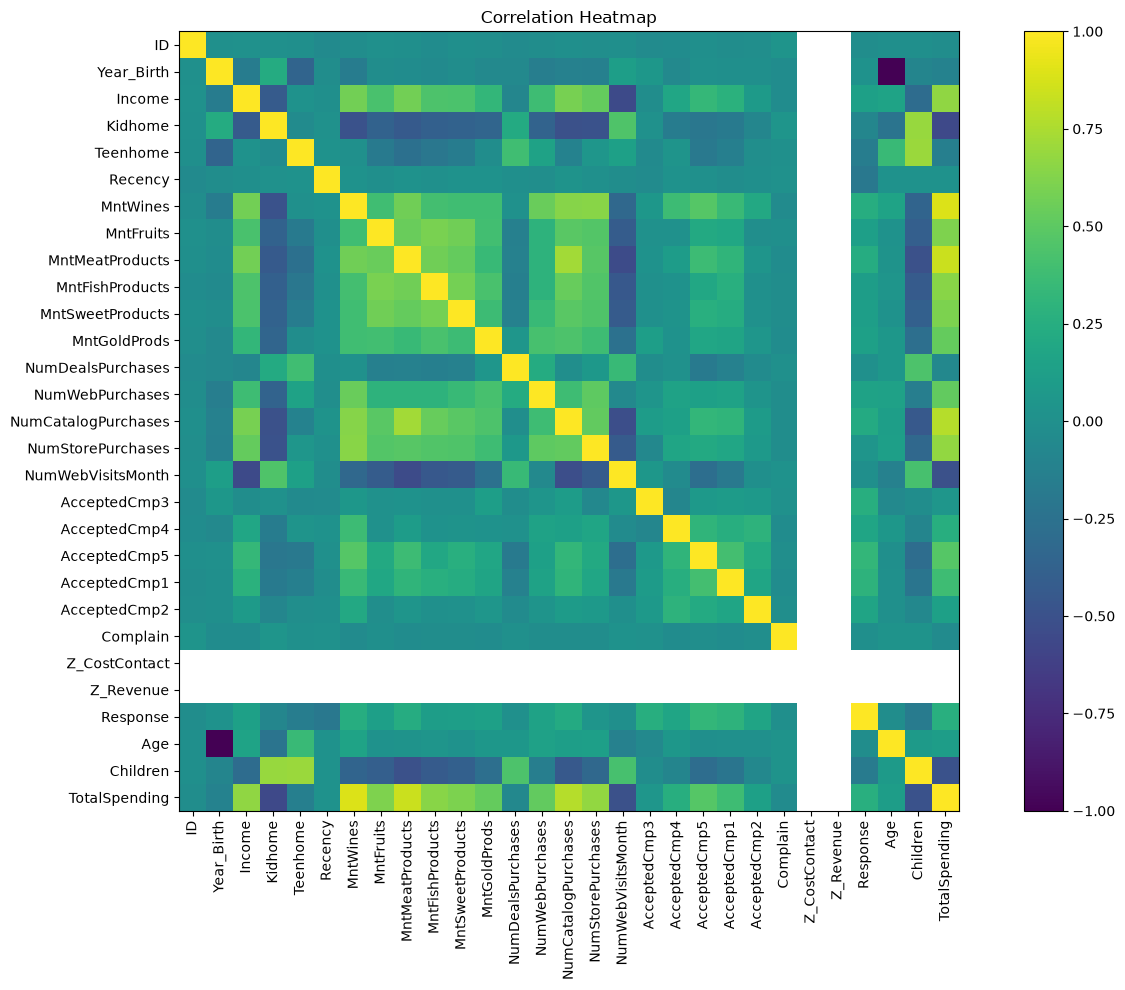

In [16]:
# Correlation of numerical columns

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(14,10))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

Outlier Detection (Boxplots)

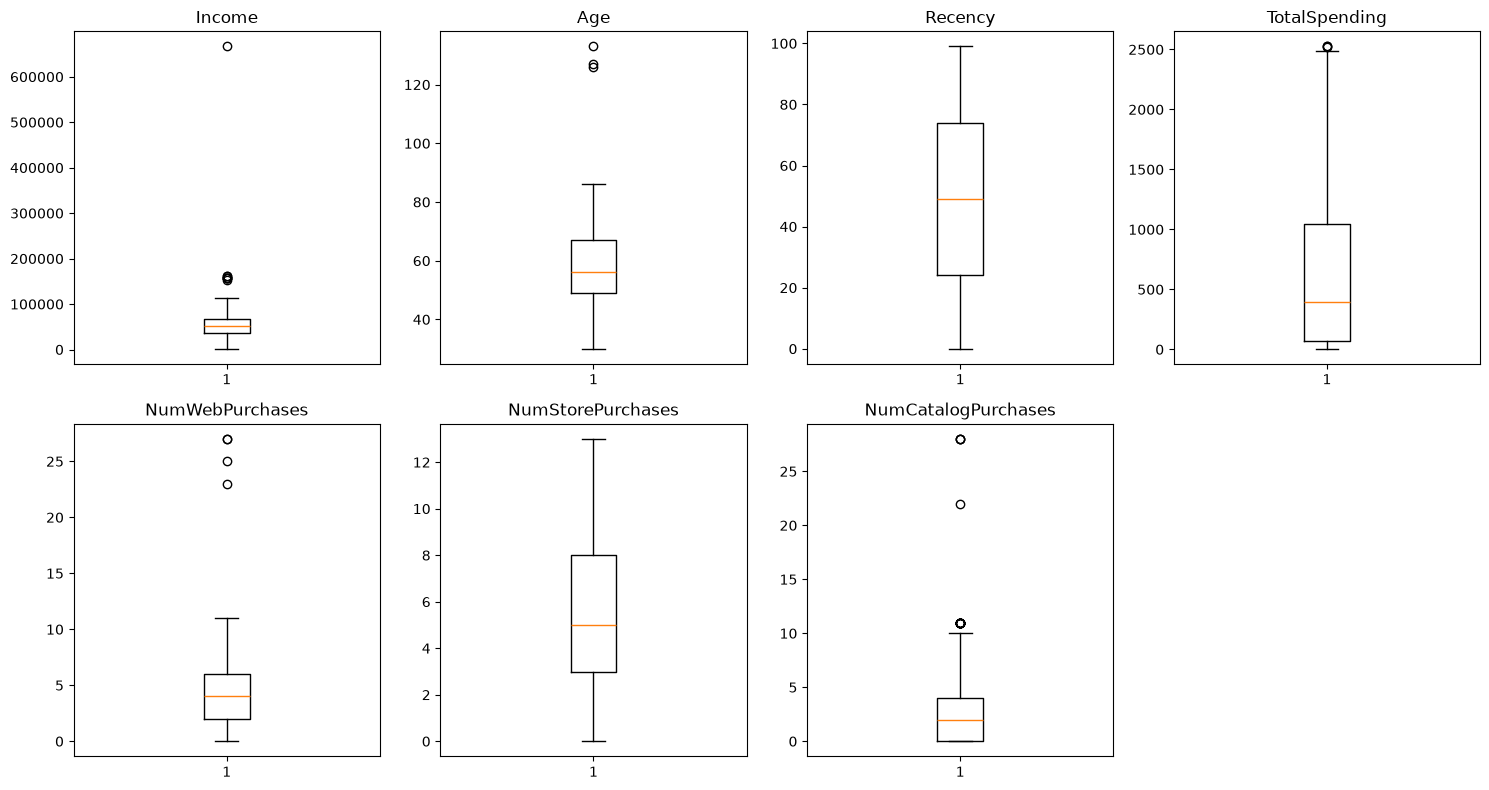

In [17]:
# Numerical Columns

numerical_cols = [
    "Income",
    "Age",
    "Recency",
    "TotalSpending",
    "NumWebPurchases",
    "NumStorePurchases",
    "NumCatalogPurchases"
]

plt.figure(figsize=(15,8))

for i, col in enumerate(numerical_cols):
    plt.subplot(2,4,i+1)
    plt.boxplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Label Encoding

In [18]:
# Encode categorical columns

encoder = LabelEncoder()

categorical_columns = [
    "Education",
    "Marital_Status"
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Children,TotalSpending
0,5524,1957,2,4,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,3,11,1,69,0,1617
1,2174,1954,2,4,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,3,11,0,72,2,27
2,4141,1965,2,5,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,3,11,0,61,0,776
3,6182,1984,2,5,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,3,11,0,42,1,53
4,5324,1981,4,3,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,3,11,0,45,1,422


Feature Selection for Clustering

In [19]:
cluster_features = [
    "Income",
    "Recency",
    "TotalSpending",
    "NumWebPurchases",
    "NumStorePurchases",
    "NumCatalogPurchases",
    "NumDealsPurchases",
    "NumWebVisitsMonth",
    "Children",
    "Age"
]

X_cluster = df[cluster_features]

X_cluster.head()

,Income,Recency,TotalSpending,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,NumDealsPurchases,NumWebVisitsMonth,Children,Age
0,58138.0,58,1617,8,4,10,3,7,0,69
1,46344.0,38,27,1,2,1,2,5,2,72
2,71613.0,26,776,8,10,2,1,4,0,61
3,26646.0,26,53,2,4,0,2,6,1,42
4,58293.0,94,422,5,6,3,5,5,1,45


Feature Scaling

In [20]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

print("Scaled Dataset Shape :", X_scaled.shape)

Scaled Dataset Shape : (2240, 10)


Elbow Method

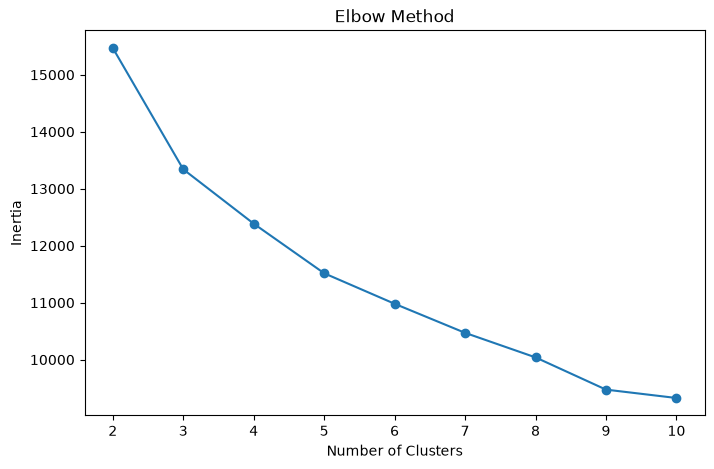

In [21]:
from sklearn.cluster import KMeans

inertia = []

K = range(2,11)

for k in K:
    
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_scaled)
    
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

Silhouette Score

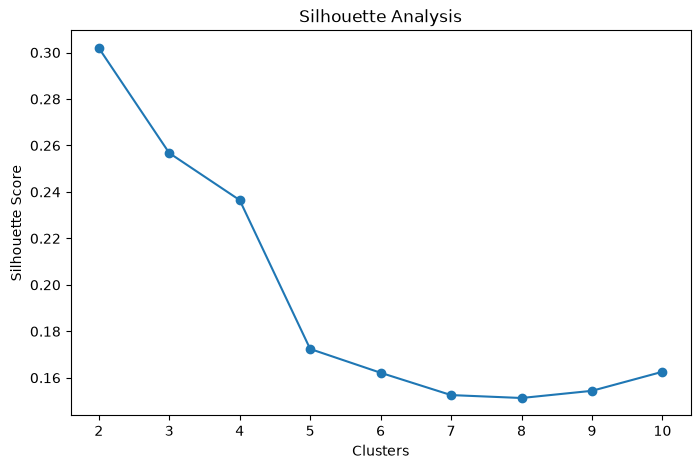

[0.30194866682395466, 0.2567435613050965, 0.23646745214558357, 0.1724098945943827, 0.16216241719993452, 0.15255495870869484, 0.15130075741082097, 0.1543903940102644, 0.1625859294204009]


In [22]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    
    scores.append(score)

plt.figure(figsize=(8,5))

plt.plot(range(2,11), scores, marker='o')

plt.xlabel("Clusters")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis")

plt.show()

print(scores)

Final K-Means Model

In [23]:
# Select best k after observing graphs
# Example: k = 4

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Children,TotalSpending,Cluster
0,5524,1957,2,4,58138.0,0,0,04-09-2012,58,635,...,0,0,0,3,11,1,69,0,1617,3
1,2174,1954,2,4,46344.0,1,1,08-03-2014,38,11,...,0,0,0,3,11,0,72,2,27,1
2,4141,1965,2,5,71613.0,0,0,21-08-2013,26,426,...,0,0,0,3,11,0,61,0,776,3
3,6182,1984,2,5,26646.0,1,0,10-02-2014,26,11,...,0,0,0,3,11,0,42,1,53,1
4,5324,1981,4,3,58293.0,1,0,19-01-2014,94,173,...,0,0,0,3,11,0,45,1,422,2


PCA Visualization

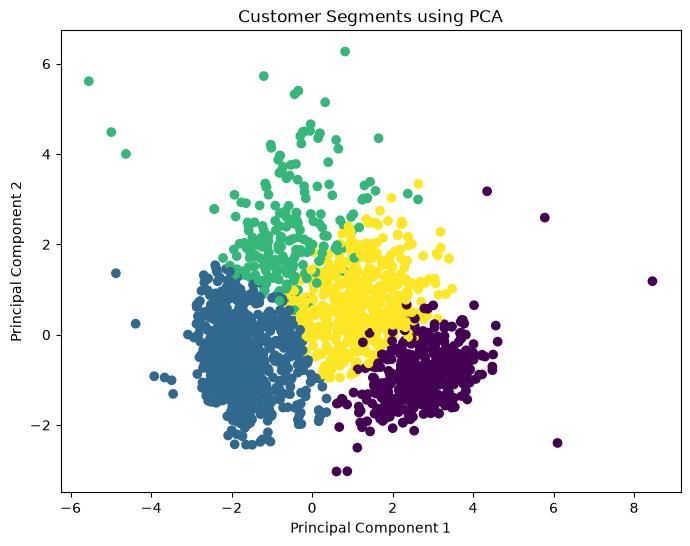

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    pca_features[:,0],
    pca_features[:,1],
    c=df["Cluster"]
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("Customer Segments using PCA")

plt.show()

Cluster-wise Customer Count

Cluster
0     467
1    1006
2     241
3     526
Name: count, dtype: int64


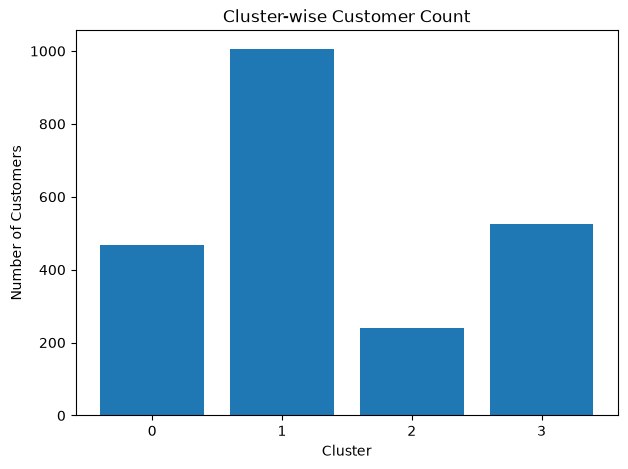

In [25]:
cluster_count = df["Cluster"].value_counts().sort_index()

print(cluster_count)

plt.figure(figsize=(7,5))

plt.bar(cluster_count.index.astype(str), cluster_count.values)

plt.xlabel("Cluster")

plt.ylabel("Number of Customers")

plt.title("Cluster-wise Customer Count")

plt.show()

Cluster Profiling

In [26]:
cluster_profile = df.groupby("Cluster")[[
    "Income",
    "TotalSpending",
    "Recency",
    "Age",
    "NumWebPurchases",
    "NumStorePurchases",
    "NumCatalogPurchases"
]].mean()

cluster_profile

,Income,TotalSpending,Recency,Age,NumWebPurchases,NumStorePurchases,NumCatalogPurchases
Cluster,,,,,,,
0,79574.546039,1399.468951,51.278373,57.374732,4.488223,8.216274,6.254818
1,34621.972664,93.379722,49.288270,54.610338,2.049702,3.188867,0.532803
2,49801.890041,547.634855,48.659751,58.721992,5.917012,6.078838,2.352697
3,62775.269962,907.825095,47.047529,61.275665,6.779468,8.479087,3.686312


Prepare Data for Regression


In [27]:
from sklearn.model_selection import train_test_split

regression_features = [
    "Income",
    "Age",
    "Recency",
    "Children",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumDealsPurchases",
    "NumWebVisitsMonth"
]

X = df[regression_features]

y = df["TotalSpending"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)



(1792, 9)
(448, 9)


Train Linear Regression

In [28]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

Evaluate Linear Regression

In [29]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, linear_predictions)

mse = mean_squared_error(y_test, linear_predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Performance")

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

Linear Regression Performance
MAE : 200.21685229096667
MSE : 91192.52783575408
RMSE : 301.981005753266
R2 Score : 0.7435273145901224


Ridge Regression

In [30]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

ridge_predictions = ridge_model.predict(X_test)

print("Ridge Regression Completed")

Ridge Regression Completed


Evaluate Ridge Regression

In [31]:
ridge_mae = mean_absolute_error(
    y_test,
    ridge_predictions
)

ridge_mse = mean_squared_error(
    y_test,
    ridge_predictions
)

ridge_rmse = np.sqrt(ridge_mse)

ridge_r2 = r2_score(
    y_test,
    ridge_predictions
)

print("Ridge Regression Performance")

print("MAE :", ridge_mae)

print("MSE :", ridge_mse)

print("RMSE :", ridge_rmse)

print("R2 Score :", ridge_r2)

Ridge Regression Performance
MAE : 200.1855835482344
MSE : 91187.47331538062
RMSE : 301.9726366997192
R2 Score : 0.7435415300795316


Regression Prediction Plot

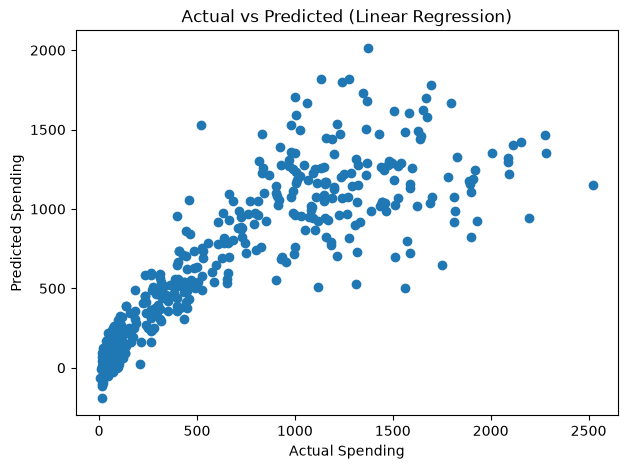

In [32]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    linear_predictions
)

plt.xlabel("Actual Spending")

plt.ylabel("Predicted Spending")

plt.title("Actual vs Predicted (Linear Regression)")

plt.show()

Prepare Data for Classification

In [33]:
classification_features = [
    "Income",
    "Age",
    "Recency",
    "Children",
    "TotalSpending",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumDealsPurchases",
    "NumWebVisitsMonth"
]

X = df[classification_features]

y = df["Response"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Logistic Regression

In [34]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train,
    y_train
)

classification_predictions = logistic_model.predict(X_test)

Evaluate Classification Model

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Accuracy :", accuracy_score(
    y_test,
    classification_predictions
))

print("Precision :", precision_score(
    y_test,
    classification_predictions
))

print("Recall :", recall_score(
    y_test,
    classification_predictions
))

print("F1 Score :", f1_score(
    y_test,
    classification_predictions
))

print("ROC AUC :", roc_auc_score(
    y_test,
    classification_predictions
))

print("\nClassification Report\n")

print(classification_report(
    y_test,
    classification_predictions
))

Accuracy : 0.8482142857142857
Precision : 0.5238095238095238
Recall : 0.15942028985507245
F1 Score : 0.24444444444444444
ROC AUC : 0.566517532790333

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.97      0.92       379
           1       0.52      0.16      0.24        69

    accuracy                           0.85       448
   macro avg       0.69      0.57      0.58       448
weighted avg       0.81      0.85      0.81       448



Confusion Matrix

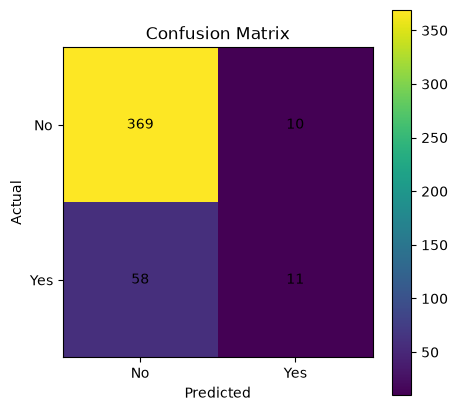

In [36]:
cm = confusion_matrix(
    y_test,
    classification_predictions
)

plt.figure(figsize=(5,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks([0,1],["No","Yes"])

plt.yticks([0,1],["No","Yes"])

plt.xlabel("Predicted")

plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center"
        )

plt.show()

GridSearchCV for Ridge Regression

In [38]:
from sklearn.model_selection import GridSearchCV

ridge_params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5,
    scoring="r2"
)

ridge_grid.fit(X_train, y_train)

print("Best Ridge Parameters:")
print(ridge_grid.best_params_)

print("\nBest R2 Score:")
print(ridge_grid.best_score_)

Best Ridge Parameters:
{'alpha': 100}

Best R2 Score:
0.16142676143892726


GridSearchCV for Logistic Regression

In [39]:
classification_X = df[classification_features]
classification_y = df["Response"]

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    classification_X,
    classification_y,
    test_size=0.2,
    random_state=42,
    stratify=classification_y
)

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"],
    "max_iter": [500, 1000]
}

grid = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train_cls, y_train_cls)

print("Best Parameters")
print(grid.best_params_)

print("\nBest Accuracy")
print(grid.best_score_)

Best Parameters
{'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}

Best Accuracy
0.8582670671169138


Evaluate Tuned Logistic Regression

In [40]:
best_model = grid.best_estimator_

pred = best_model.predict(X_test_cls)

print("Accuracy :", accuracy_score(y_test_cls, pred))

print("Precision :", precision_score(y_test_cls, pred))

print("Recall :", recall_score(y_test_cls, pred))

print("F1 Score :", f1_score(y_test_cls, pred))

print("ROC AUC :", roc_auc_score(y_test_cls, pred))

Accuracy : 0.8660714285714286
Precision : 0.6521739130434783
Recall : 0.22388059701492538
F1 Score : 0.3333333333333333
ROC AUC : 0.6014416108434207


Model Comparison Table

In [41]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Ridge Regression",
        "Logistic Regression",
        "K-Means"
    ],

    "Objective":[
        "Predict Spending",
        "Predict Spending",
        "Predict Response",
        "Customer Segmentation"
    ],

    "Performance":[
        round(r2,3),
        round(ridge_r2,3),
        round(accuracy_score(y_test_cls,pred),3),
        round(silhouette_score(X_scaled,df["Cluster"]),3)
    ]

})

comparison

,Model,Objective,Performance
0,Linear Regression,Predict Spending,0.744
1,Ridge Regression,Predict Spending,0.744
2,Logistic Regression,Predict Response,0.866
3,K-Means,Customer Segmentation,0.236


Customer Segment Summary

In [42]:
segment_summary = df.groupby("Cluster").agg({

    "Income":"mean",

    "TotalSpending":"mean",

    "Recency":"mean",

    "Age":"mean",

    "NumWebPurchases":"mean"

}).round(2)

segment_summary

,Income,TotalSpending,Recency,Age,NumWebPurchases
Cluster,,,,,
0,79574.55,1399.47,51.28,57.37,4.49
1,34621.97,93.38,49.29,54.61,2.05
2,49801.89,547.63,48.66,58.72,5.92
3,62775.27,907.83,47.05,61.28,6.78


Assign Business-Friendly Segment Names

In [43]:
segment_names = {

    0:"High Value Customers",

    1:"Regular Customers",

    2:"Potential Customers",

    3:"At Risk Customers"

}

df["SegmentName"] = df["Cluster"].map(segment_names)

df[["Cluster","SegmentName"]].head()

,Cluster,SegmentName
0,3,At Risk Customers
1,1,Regular Customers
2,3,At Risk Customers
3,1,Regular Customers
4,2,Potential Customers


Revenue Contribution by Segment

In [44]:
segment_revenue = df.groupby("SegmentName")["TotalSpending"].sum()

segment_revenue

SegmentName
At Risk Customers       477516
High Value Customers    653552
Potential Customers     131980
Regular Customers        93940
Name: TotalSpending, dtype: int64

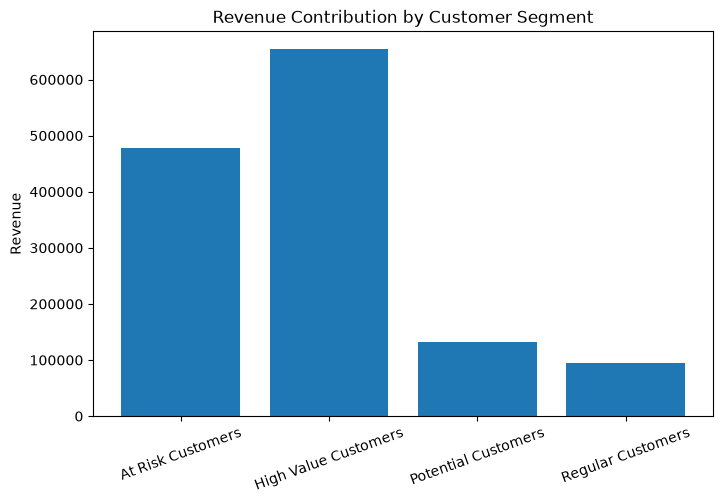

In [45]:
plt.figure(figsize=(8,5))

plt.bar(segment_revenue.index,segment_revenue.values)

plt.xticks(rotation=20)

plt.ylabel("Revenue")

plt.title("Revenue Contribution by Customer Segment")

plt.show()

Export Customer Segments

In [46]:
df.to_csv("customer_segments.csv",index=False)

print("customer_segments.csv saved successfully.")

customer_segments.csv saved successfully.


Business Insights

In [47]:
print("Business Insights")

print()

print("1. High Value Customers generate the highest revenue.")

print("2. At Risk Customers require retention campaigns.")

print("3. Regular Customers should receive loyalty rewards.")

print("4. Potential Customers should receive onboarding offers.")

print("5. Personalized recommendations can increase customer retention.")

print("6. Customers with high website activity have greater purchase potential.")

print("7. Targeted marketing improves campaign effectiveness.")

print("8. Segmentation helps optimize marketing budget allocation.")

Business Insights

1. High Value Customers generate the highest revenue.
2. At Risk Customers require retention campaigns.
3. Regular Customers should receive loyalty rewards.
4. Potential Customers should receive onboarding offers.
5. Personalized recommendations can increase customer retention.
6. Customers with high website activity have greater purchase potential.
7. Targeted marketing improves campaign effectiveness.
8. Segmentation helps optimize marketing budget allocation.


Conclusion

In [48]:
print("="*60)

print("PROJECT CONCLUSION")

print("="*60)

print()

print("Customer segmentation was successfully performed using K-Means clustering.")

print("The Elbow Method and Silhouette Score helped determine an appropriate number of clusters.")

print("Linear and Ridge Regression were used to predict customer spending.")

print("Logistic Regression successfully predicted customer campaign response.")

print("GridSearchCV improved the classification model by identifying better hyperparameters.")

print("The resulting customer segments provide actionable insights for marketing, customer retention, and personalized recommendations.")

print()

print("Project Completed Successfully.")

PROJECT CONCLUSION

Customer segmentation was successfully performed using K-Means clustering.
The Elbow Method and Silhouette Score helped determine an appropriate number of clusters.
Linear and Ridge Regression were used to predict customer spending.
Logistic Regression successfully predicted customer campaign response.
GridSearchCV improved the classification model by identifying better hyperparameters.
The resulting customer segments provide actionable insights for marketing, customer retention, and personalized recommendations.

Project Completed Successfully.
